In [4]:
import urllib.request
import json

import paths
import importlib
import xarray as xr
import os
import geopandas as gpd
import pandas as pd
import torch

from tqdm import tqdm
from matplotlib import gridspec
from download_data import nrfa_api, download_shapefiles, download_nrfa
from download_data.download_nrfa import download_csv
from train_model import load_data, train
from train_model import RE_utils as ut
from apollo import mechanics as ma
from apollo import era5 as er
from preprocessing import catchment_characteristics as cc

importlib.reload(paths)
importlib.reload(nrfa_api)
importlib.reload(download_shapefiles)
importlib.reload(train)

<module 'train_model.train' from '/Users/av656/Documents/Cambridge/PhD Research/Coding/Lowlands-vs_highlands-streamflow/train_model/train.py'>

In [5]:
station_ids = nrfa_api.get_all_stations_id()
print(len(station_ids))

1601


In [6]:
importlib.reload(er)

<module 'apollo.era5' from '/Users/av656/Documents/Cambridge/PhD Research/Coding/Lowlands-vs_highlands-streamflow/apollo/era5.py'>

In [26]:
def update_rain_status(log_path, data_dir):
    """
    Update the log file: if id_nrfa.csv is missing for a station,
    set rain_success to False and status to 'partial'.

    Parameters
    ----------
    log_path : str
        Path to the JSON log file.
    data_dir : str
        Directory where `id_nrfa.csv` files are expected.

    Returns
    -------
    None. Updates the log file in-place.
    """
    # Load log
    with open(log_path, 'r') as f:
        log = json.load(f)

    updated = False
    for sid, entry in log.items():
        csv_path = os.path.join(data_dir, sid, f"{sid}_nrfa.csv")
        print(csv_path)
        if not os.path.exists(csv_path):
            if entry.get("rain_success", True) or entry.get("status") == "success":
                entry["rain_success"] = False
                entry["status"] = "partial"
                updated = True
                print(f"⚠️ Missing: {sid}_nrfa.csv → marked as partial")
        else:
            entry["rain_success"] = True
            entry["status"] = "success"

    # Save only if there were changes
    if updated:
        with open(log_path, 'w') as f:
            json.dump(log, f, indent=2)
        print("✅ Log updated and saved.")
    else:
        print("✔️ All files present. No changes made.")

In [27]:
update_rain_status(download_nrfa.LOG_IDS_PATH, paths.CATCHMENT_BASINS)

/Users/av656/Documents/Cambridge/PhD Research/Coding/Lowlands-vs_highlands-streamflow/data/catchment_basins/2001/2001_nrfa.csv
/Users/av656/Documents/Cambridge/PhD Research/Coding/Lowlands-vs_highlands-streamflow/data/catchment_basins/3002/3002_nrfa.csv
/Users/av656/Documents/Cambridge/PhD Research/Coding/Lowlands-vs_highlands-streamflow/data/catchment_basins/3003/3003_nrfa.csv
/Users/av656/Documents/Cambridge/PhD Research/Coding/Lowlands-vs_highlands-streamflow/data/catchment_basins/3004/3004_nrfa.csv
/Users/av656/Documents/Cambridge/PhD Research/Coding/Lowlands-vs_highlands-streamflow/data/catchment_basins/4001/4001_nrfa.csv
/Users/av656/Documents/Cambridge/PhD Research/Coding/Lowlands-vs_highlands-streamflow/data/catchment_basins/4003/4003_nrfa.csv
/Users/av656/Documents/Cambridge/PhD Research/Coding/Lowlands-vs_highlands-streamflow/data/catchment_basins/6007/6007_nrfa.csv
/Users/av656/Documents/Cambridge/PhD Research/Coding/Lowlands-vs_highlands-streamflow/data/catchment_basins/600

In [34]:
importlib.reload(paths)

<module 'paths' from '/Users/av656/Documents/Cambridge/PhD Research/Coding/Lowlands-vs_highlands-streamflow/paths.py'>

In [37]:
os.path.exists("~/gdrive")

False

In [33]:
download_nrfa.download_csv(33040, 'cdr')

33040
https://nrfaapps.ceh.ac.uk/nrfa/ws/time-series?station=33040&data-type=cdr&format=json-object


False

In [7]:


for yy in [1980]:

    filename = paths.WEATHER_UK + '/Rainfall/Rainfall_' + str(yy)

    # Shift the daily aggregation (from 9am to 9am)
    #if not os.path.exists(filename + '_9to9.nc'):
    print('shifting', filename)
    er.aggregate_9to9(filename + '.nc',
                          paths.WEATHER_UK + '/Rainfall/Rainfall_' + str(yy + 1) + '.nc',
                          int(yy),
                          filename + '_9to9.nc')

shifting /Users/av656/Documents/Cambridge/PhD Research/Coding/Lowlands-vs_highlands-streamflow/data/weather_UK/Rainfall/Rainfall_1980


In [15]:
xr.open_dataset(paths.WEATHER_UK + '/Rainfall/Rainfall_2021_aggregated_9to9.nc')

<xarray.Dataset> Size: 7MB
Dimensions:     (valid_time: 365, latitude: 49, longitude: 49)
Coordinates:
    number      int64 8B ...
  * latitude    (latitude) float64 392B 60.0 59.75 59.5 ... 48.5 48.25 48.0
  * longitude   (longitude) float64 392B -8.0 -7.75 -7.5 -7.25 ... 3.5 3.75 4.0
  * valid_time  (valid_time) datetime64[ns] 3kB 2021-01-01 ... 2021-12-31
Data variables:
    tp          (valid_time, latitude, longitude) float32 4MB ...
    smlt        (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-07-02T13:16 GRIB to CDM+CF via cfgrib-0.9.1...

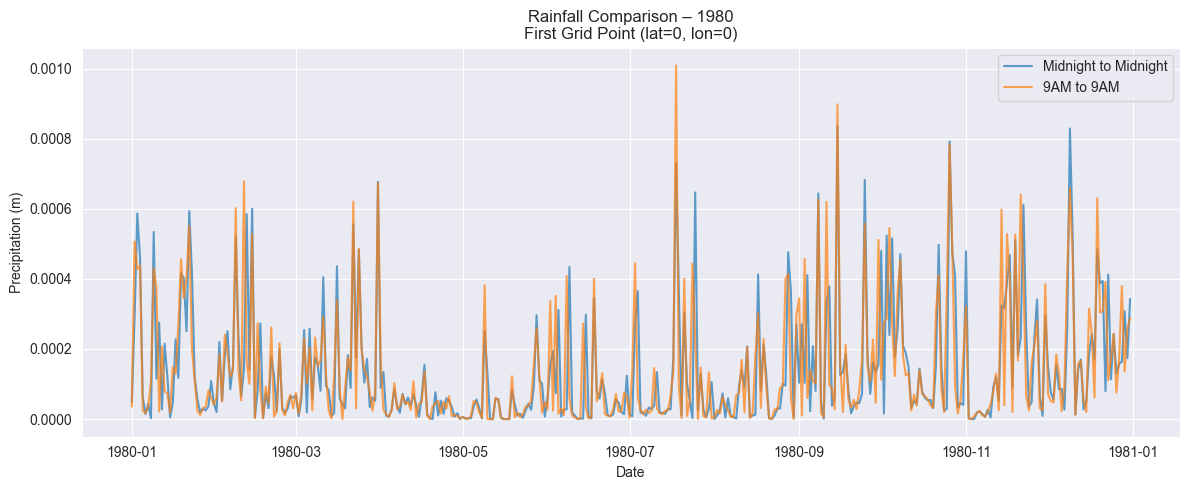

In [11]:
import xarray as xr
import matplotlib.pyplot as plt

# File paths (adjust if needed)
yy = 1980
base_path = paths.WEATHER_UK + f"/Rainfall/Rainfall_{yy}"
file_normal = base_path + "_aggregated.nc"
file_9to9   = base_path + "_9to9.nc"

# Load datasets
ds_normal = xr.open_dataset(file_normal)
ds_9to9 = xr.open_dataset(file_9to9)

# Extract first lat/lon point
rain_normal = ds_normal.tp.isel(latitude=0, longitude=0)
rain_9to9 = ds_9to9.tp.isel(latitude=0, longitude=0)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(rain_normal.valid_time, rain_normal, label='Midnight to Midnight', alpha=0.7)
plt.plot(rain_9to9.valid_time, rain_9to9, label='9AM to 9AM', alpha=0.7)

plt.title("Rainfall Comparison – 1980\nFirst Grid Point (lat=0, lon=0)")
plt.xlabel("Date")
plt.ylabel("Precipitation (m)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


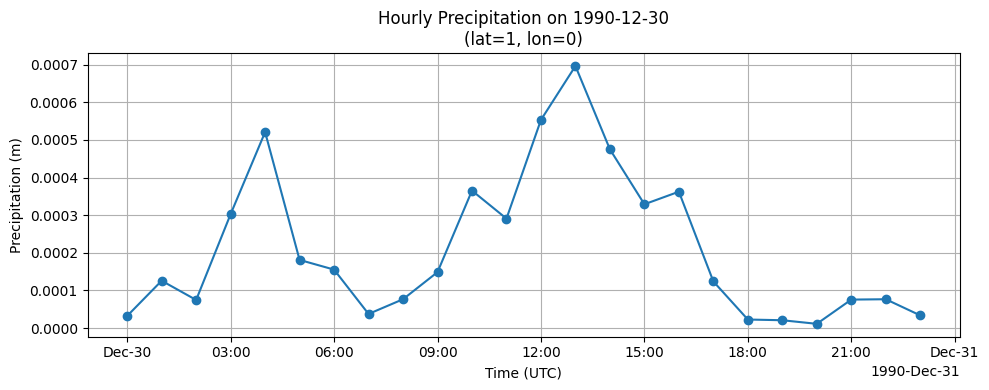

In [59]:
import matplotlib.pyplot as plt

# Select the 24 hourly values for 1990-12-30
subset = original.tp.sel(
    valid_time=slice('1990-12-30T00:00', '1990-12-30T23:59')
).isel(latitude=1, longitude=0)

# Plot
plt.figure(figsize=(10, 4))
subset.plot(marker='o')
plt.title("Hourly Precipitation on 1990-12-30\n(lat=1, lon=0)")
plt.ylabel("Precipitation (m)")
plt.xlabel("Time (UTC)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [56]:
original.tp.sel(valid_time='1990-12-30').isel(latitude=1, longitude=0).sum(dim='valid_time')

<xarray.DataArray 'tp' ()> Size: 4B
array(0.00509405, dtype=float32)
Coordinates:
    number     int64 8B ...
    latitude   float64 8B 59.75
    longitude  float64 8B -8.0

In [57]:
daily_rainfall_9to9.sel(floor='1990-12-30').isel(latitude=1, longitude=0)

<xarray.DataArray 'tp' ()> Size: 4B
array(0.00434923, dtype=float32)
Coordinates:
    number     int64 8B ...
    latitude   float64 8B 59.75
    longitude  float64 8B -8.0
    floor      datetime64[ns] 8B 1990-12-30
Attributes: (12/32)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      2401
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:                                    m
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [37]:
filename = paths.WEATHER_UK + f'/Rainfall/Rainfall_{yy}_aggregated.nc'
aggregated = xr.open_dataset(filename)
aggregated.tp.values

array([[[1.74880028e-04, 1.67310238e-04, 1.59641102e-04, ...,
         8.70823860e-05, 7.31547698e-05, 4.80214767e-05],
        [2.18153000e-04, 2.10106373e-04, 2.02039882e-04, ...,
         8.42412337e-05, 6.94990158e-05, 5.60879707e-05],
        [2.24252537e-04, 2.21908092e-04, 2.17556953e-04, ...,
         9.31819304e-05, 7.86582605e-05, 6.53664247e-05],
        ...,
        [9.41952094e-05, 9.20295715e-05, 9.97583047e-05, ...,
         1.52985251e-06, 1.33117044e-06, 7.94728578e-07],
        [9.36587676e-05, 9.96589661e-05, 1.09990440e-04, ...,
         6.55651093e-07, 7.54992186e-07, 1.19209290e-06],
        [8.39829445e-05, 8.58108178e-05, 1.04526676e-04, ...,
         2.98023224e-07, 3.17891448e-07, 6.15914644e-07]],

       [[1.28348665e-05, 1.26759214e-05, 1.23182936e-05, ...,
         1.19427837e-04, 1.66118145e-04, 2.24928066e-04],
        [2.99811363e-05, 2.78353691e-05, 2.51134243e-05, ...,
         8.18371773e-05, 1.08460583e-04, 1.94648906e-04],
        [4.04914208e-05, 

In [58]:
aggregated.tp.sel(valid_time='1990-12-30').isel(latitude=1, longitude=0)

<xarray.DataArray 'tp' ()> Size: 4B
array(0.000212, dtype=float32)
Coordinates:
    number      int64 8B ...
    latitude    float64 8B 59.75
    longitude   float64 8B -8.0
    valid_time  datetime64[ns] 8B 1990-12-30
Attributes: (12/32)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      2401
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:                                    m
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [ ]:
"""
    if not os.path.exists(filename + '_9to9.nc'):
        print('shifting', filename)
        er.shift_time_9am_to_9am(str(rain_query['file_stem']) + '.nc',
                                 int(yy),
                                 str(rain_query['file_stem']) + '_9to9.nc')
        er.aggregate_mean(str(rain_query['file_stem']) + '_9to9.nc',
                          str(rain_query['file_stem']) + '_aggregated_9to9.nc',
                          shift=9)
"""

In [6]:
file_robert = pd.read_csv(paths.DATA + '/nrfa-station-metadata.csv')
file_robert

,id,name,catchment-area,easting,northing,latitude,longitude,river,location,station-level,...,mean-flood-plain-depth,mean-flood-plain-location,mean-flood-plain-extent,urbext-1990,urbconc-1990,urbloc-1990,urbext-2000,urbconc-2000,urbloc-2000,data-summary
0,1001,Wick at Tarroul,161.9,326202.0,954915.0,58.47620,-3.26706,Wick,Tarroul,13.0,...,0.763,0.928,0.0922,0.0004,NaN,NaN,0.0012,NaN,NaN,gdf;gmf;cmr;cdr;cdr-d
1,2001,Helmsdale at Kilphedir,551.4,299839.0,918163.0,58.14100,-3.70295,Helmsdale,Kilphedir,17.0,...,0.671,1.069,0.0555,0.0000,NaN,NaN,0.0000,NaN,NaN,gdf;gmf;cmr;cdr;cdr-d;pot-stage;pot-flow;gaugi...
2,2002,Brora at Bruachrobie,434.4,289156.0,903916.0,58.01056,-3.87757,Brora,Bruachrobie,9.0,...,0.705,1.024,0.0553,0.0000,NaN,NaN,0.0002,NaN,NaN,gdf;gmf;cmr;cdr;cdr-d;pot-stage;pot-flow;gaugi...
3,3001,Shin at Lairg,494.6,258100.0,906200.0,58.02222,-4.40405,Shin,Lairg,81.7,...,0.742,0.893,0.0621,0.0000,NaN,NaN,0.0000,NaN,NaN,gdf;gmf;cmr;cdr;cdr-d
4,3002,Carron at Sgodachail,241.1,249136.0,892152.0,57.89321,-4.54668,Carron,Sgodachail,70.7,...,0.633,0.863,0.0377,0.0000,NaN,NaN,0.0000,NaN,NaN,gdf;gmf;cmr;cdr;cdr-d;pot-stage;pot-flow;gaugi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1596,206002,Jerretspass at Jerretspass,107.8,306487.0,333187.0,54.23652,-6.36758,Jerretspass,Jerretspass,11.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,gdf;gmf
1597,206006,Annalong at Recorder,13.8,335000.0,323100.0,54.13925,-5.93509,Annalong,Recorder,NaN,...,0.292,0.820,0.0230,0.0000,NaN,NaN,0.0000,NaN,NaN,cmr;cdr;cdr-d;pot-flow;amax-flow
1598,236005,Colebrooke at Ballindarragh Bridge,313.6,233195.0,335906.0,54.27093,-7.49124,Colebrooke,Ballindarragh Bridge,53.0,...,0.878,0.811,0.0819,0.0067,NaN,0.645,0.0012,NaN,NaN,gdf;gmf;cmr;cdr;cdr-d;pot-stage;pot-flow;gaugi...
1599,236007,Sillees at Drumrainey Bridge,166.3,220486.0,340003.0,54.30840,-7.68602,Sillees,Drumrainey Bridge,44.0,...,2.282,0.844,0.1622,0.0020,NaN,NaN,0.0006,NaN,NaN,gdf;gmf;cmr;cdr;cdr-d;pot-stage;pot-flow;gaugi...


In [11]:
full_pressure_data = xr.open_mfdataset(paths.WEATHER_UK + '/Pressure/Pressure_*.nc', concat_dim='valid_time', combine='nested', engine='netcdf4')

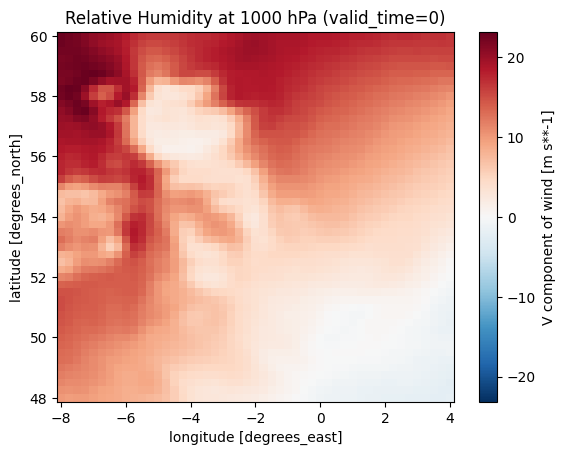

In [13]:
import xarray as xr
import matplotlib.pyplot as plt

# Open the file
ds = xr.open_dataset(paths.DATA + '/weather_UK/Pressure/Pressure_20071000hPa.nc')
ds = full_pressure_data 

# Choose a time slice and squeeze singleton dims
r = ds['v'].sel(pressure_level=1000).isel(valid_time=50).squeeze()

# Plot as 2D map
r.plot()
plt.title("Relative Humidity at 1000 hPa (valid_time=0)")
plt.show()

In [81]:
days = 6

years_train = [1981 + i for i in range(30)]
years_eval = [2010 + i for i in range(10)]

features = (['Rain'] + ['Rain-' + f'{d+1}' for d in range(days)] 
            + ['Temperature'] + ['Temperature-' + f'{d+1}' for d in range(days)] \
            + ['Resultant Windspeed'] + ['Resultant Windspeed-' + f'{d+1}' for d in range(days)] \
            + ['Humidity'] + ['Humidity-' + f'{d+1}' for d in range(days)]\
            #+ ['Soil Moisture ' + f'{i+1}' for i in range(4)])
            + ['Rain_28_Mu','Rain_90_Mu','Rain_180_Mu', 'Temperature_28_Mu','Temperature_90_Mu','Temperature_180_Mu']) 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [87]:
def train_NN(rf, years_train, years_eval, features=features, loss_func=None, alpha=1.0, beta=1.0, grid_search=False, early_stopping=True, verbose=True, network_params={}):

    # LOAD DATA
    trnset, full_set = load_data.preprocess_data(rf, features, years_eval, years_train)
    targets = ['Flow']
    xspace = ma.featurelocator(rf, features)
    yspace = ma.featurelocator(rf, targets)

    x_train = load_data.reshape_input(trnset, xspace)
    y_train = load_data.reshape_output(trnset, yspace)   
    
    psi = ut.psi_distribution(y_train, 'lognorm', alpha=alpha, beta=beta, plot=False)
    
    # TRAINING
    network = train.train(x_train, 
                          y_train,
                          verbose=verbose, 
                          loss_func_type=loss_func, 
                          psi=psi[:len(x_train)], 
                          grid_search=grid_search, 
                          early_stopping=early_stopping,
                          network_params=network_params)

    # EVALUATION
    x_eval = load_data.reshape_input(full_set, xspace)  
    y_eval = load_data.reshape_input(full_set, yspace)  
    
    rf.loc[:, 'Predicted'] = network.predict(torch.from_numpy(x_eval).to(device))
    rf.loc[:, 'Groundtruth'] = y_eval    
    rf['Date'] =  pd.to_datetime(rf['Date'], unit='s')
    rf = rf[rf['Date'].dt.year.isin(years_train + years_eval)]
    rf.reset_index(drop=True, inplace=True)
    return rf, network

In [220]:
## MODEL TRAINING + PREDICTIONS

input_type = ''
days = 6

for station_nr in tqdm(os.listdir(paths.CATCHMENT_BASINS), desc="Processing Stations"):
    
    out_path = paths.PREDICTIONS + f"/era5/{station_nr}_era5.csv"
    
    if not os.path.exists(out_path):
        catchment_boundary = gpd.read_file(paths.CATCHMENT_BASINS + '/' + str(station_nr) + '/' + str(station_nr) + '.shp')
    
        original_data = pd.read_csv(paths.CATCHMENT_BASINS + '/' + str(station_nr) + '/' + str(station_nr) + f"_lumped{input_type}.csv", low_memory=False)
        original_data['Date'] = pd.to_datetime(original_data['Date'], format='%Y-%m-%d').dt.date
        subset = ['Flow'] + ['Rain'] + ['Rain-' + f'{d+1}' for d in range(days)] + ['Rain_28_Mu','Rain_90_Mu','Rain_180_Mu']
        clean_data = original_data #.dropna(subset=subset)
        print(len(clean_data))
        expanded_features = features + ['Snow'] + ['Snow-' + f'{d+1}' for d in range(days)]
    
        outdf, network = train_NN(rf=clean_data, years_train=years_train, years_eval=years_eval, features=expanded_features, loss_func=None, alpha=1, beta=2, grid_search=False, verbose=False)
        outdf.to_csv(out_path)

Processing Stations:   0%|          | 0/251 [00:00<?, ?it/s]

15527


Processing Stations:  15%|█▌        | 38/251 [00:10<01:01,  3.49it/s]

15519


Processing Stations:  16%|█▌        | 39/251 [00:22<02:30,  1.41it/s]

...

15527


Processing Stations:  22%|██▏       | 54/251 [02:09<19:27,  5.93s/it]

15114


Processing Stations:  22%|██▏       | 54/251 [02:16<08:17,  2.52s/it]


KeyboardInterrupt: 

In [110]:
importlib.reload(cc)

<module 'preprocessing.catchment_characteristics' from '/Users/av656/Documents/Cambridge/PhD Research/Coding/Lowlands-vs_highlands-streamflow/preprocessing/catchment_characteristics.py'>

In [175]:
all_files = os.listdir(paths.PREDICTIONS + '/era5')

# Filter only *_era5.csv files and extract station numbers
station_numbers = [
    filename.split('_')[0]
    for filename in all_files
    if filename.endswith('_era5.csv')
]

In [210]:
importlib.reload(cc)

<module 'preprocessing.catchment_characteristics' from '/Users/av656/Documents/Cambridge/PhD Research/Coding/Lowlands-vs_highlands-streamflow/preprocessing/catchment_characteristics.py'>

In [221]:
## PERFORMANCE PLOT

input_type = 'era5'

overview_gdf = cc.get_characteristics_all_stations(station_numbers, 
                                                   input_type=input_type, 
                                                   years_eval=years_eval)
"""
params_to_plot = ['Area', 'Latitude', 'HE_mean', 'Slope gradient']
labels_to_plot = ['Catchment Area [m^2]', 'Latitude [°]', 'Hydrological Efficiency [mm/day]', 'Slope gradient [%]']
colormap_param = 'Latitude' #'90 percentile'
"""

params_to_plot = ['Latitude']
labels_to_plot = ['Latitude [°]']
colormap_param = 'Latitude' 

catchment_dict ={'7001':'Findhorn',
                 '33039':'Bedford Ouse',
                 '54057':'Severn'}

fig = plt.figure(figsize=(16, 6))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 0.015])
axes = [fig.add_subplot(gs[i // 2, i % 2]) for i in range(4)]

cmap = plt.get_cmap('viridis')
norm = plt.Normalize(overview_gdf[colormap_param].min(), overview_gdf[colormap_param].max())

# Plot each parameter in its respective subplot
for i, param in enumerate(params_to_plot):
    if i < 4:
        sc = axes[i].scatter(overview_gdf[param], overview_gdf['NSE'], c=overview_gdf[colormap_param], cmap=cmap, norm=norm, marker='o', s=35)
        axes[i].set_xlabel(labels_to_plot[i], weight='bold', size=12)
        if i == 1 or i == 23:
            axes[i].set_yticklabels([])
            
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        axes[i].tick_params(axis='both', labelsize=12)
        
        # Add station names next to the focus catchments
        for j, row in overview_gdf.iterrows():
            if row['Station'] in ['7001','33039','54057']:
                x_offset = (overview_gdf[param].max()-overview_gdf[param].min())/100
                y_offset = 0.01
                axes[i].text(row[param] + x_offset, row['NSE'] + y_offset, catchment_dict.get(row['Station']), fontsize=11, ha='left')
        
        axes[i].grid(True)

# Add colorbar to indicate latitude
cax = fig.add_subplot(gs[:, 2]) 
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax, orientation='vertical', label='Altitude [m]')
cbar.ax.yaxis.label.set_weight('bold')
cbar.ax.tick_params(labelsize=12)
cbar.ax.yaxis.label.set_size(12)
fig.supylabel('Normalized Squared Error (NSE)', weight='bold', size=12)

plt.tight_layout(rect=[0, 0, 0.95, 1])
plt.show()

ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [222]:
import matplotlib.pyplot as plt

def plot_prediction(df_predictions, variable_to_plot):
    df_predictions['Date'] = pd.to_datetime(df_predictions['Date'])

    plt.figure(figsize=(10, 4))
    plt.plot(df_predictions['Date'], df_predictions[variable_to_plot], label='Predicted Flow')
    plt.xlabel('Date')
    plt.ylabel('Flow')
    plt.title('Streamflow Prediction')
    plt.legend()
    plt.tight_layout()
    plt.grid(True)
    plt.show()

In [223]:
df_predictions = pd.read_csv(paths.CATCHMENT_BASINS + '/2001/2001_lumped_nrfa.csv')
#df_predictions = pd.read_csv(paths.PREDICTIONS + '/era5/8006_era5.csv')

In [224]:
df_predictions['Parsed_Date'] = pd.to_datetime(df_predictions['Date'], errors='coerce')

# Find rows where the conversion failed (invalid dates)
invalid_date_rows = df_predictions[df_predictions['Parsed_Date'].isna()]
invalid_date_rows

,Unnamed: 0.1,Date,Rain,Rain-1,Rain-2,Rain-3,Rain-4,Rain-5,Rain-6,Rain-7,...,Humidity-22,Humidity-23,Humidity-24,Humidity-25,Humidity-26,Humidity-27,Humidity_28_Mu,Humidity_90_Mu,Humidity_180_Mu,Parsed_Date


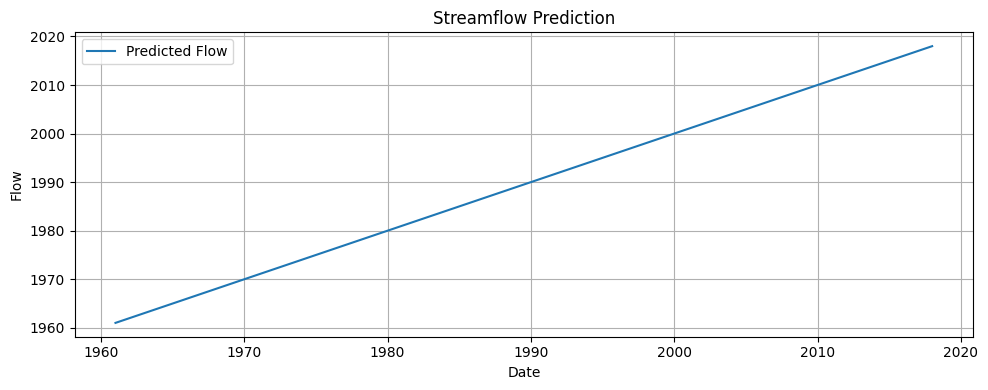

In [190]:
plot_prediction(df_predictions, 'Date')

In [188]:
df_predictions.columns

Index(['Unnamed: 0.1', 'Date', 'Rain', 'Rain-1', 'Rain-2', 'Rain-3', 'Rain-4',
       'Rain-5', 'Rain-6', 'Rain-7',
       ...
       'Humidity-21', 'Humidity-22', 'Humidity-23', 'Humidity-24',
       'Humidity-25', 'Humidity-26', 'Humidity-27', 'Humidity_28_Mu',
       'Humidity_90_Mu', 'Humidity_180_Mu'],
      dtype='object', length=165)

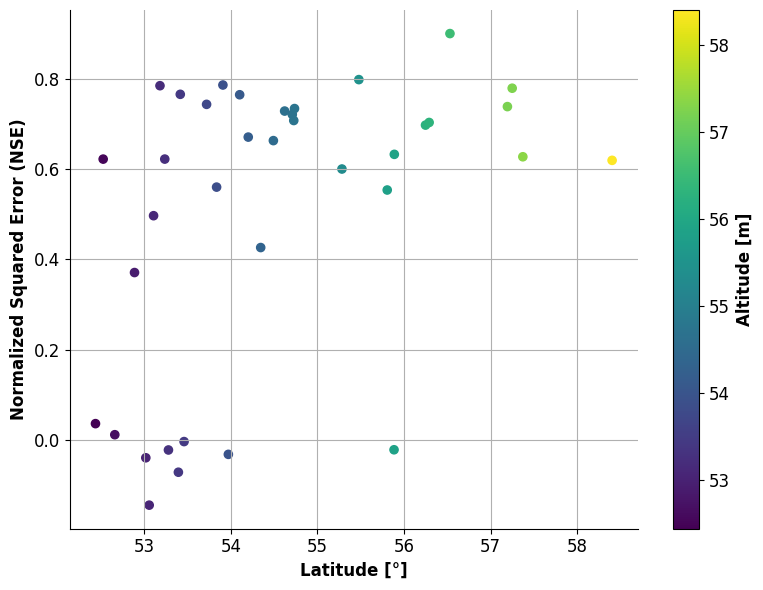

In [225]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl

input_type = 'era5'

overview_gdf = cc.get_characteristics_all_stations(
    station_numbers, 
    input_type=input_type, 
    years_eval=years_eval
)

# Set the parameter and label
param = 'Latitude'
label = 'Latitude [°]'
colormap_param = 'Latitude'  # Can change to another param if needed

catchment_dict = {
    '7001': 'Findhorn',
    '33039': 'Bedford Ouse',
    '54057': 'Severn'
}

# Set up figure
fig, ax = plt.subplots(figsize=(8, 6))

# Create color map
cmap = plt.get_cmap('viridis')
norm = plt.Normalize(overview_gdf[colormap_param].min(), overview_gdf[colormap_param].max())

# Scatter plot
sc = ax.scatter(
    overview_gdf[param], 
    overview_gdf['NSE'], 
    c=overview_gdf[colormap_param], 
    cmap=cmap, 
    norm=norm,
    s=35
)

ax.set_xlabel(label, weight='bold', size=12)
ax.set_ylabel('Normalized Squared Error (NSE)', weight='bold', size=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', labelsize=12)
ax.grid(True)

# Add station names next to the selected catchments
x_offset = (overview_gdf[param].max() - overview_gdf[param].min()) / 100
y_offset = 0.01
for _, row in overview_gdf.iterrows():
    if row['Station'] in catchment_dict:
        ax.text(row[param] + x_offset, row['NSE'] + y_offset, catchment_dict[row['Station']], fontsize=11, ha='left')

# Add colorbar
cbar = plt.colorbar(sc, ax=ax, orientation='vertical')
cbar.set_label('Altitude [m]', weight='bold', size=12)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

In [226]:
overview_era5_gdf = cc.get_characteristics_all_stations( station_numbers, 
    input_type='era5', 
    years_eval=years_eval
)

overview_nrfa_gdf = cc.get_characteristics_all_stations(station_numbers, 
    input_type='nrfa', 
    years_eval=years_eval
)

comparison = overview_era5_gdf.merge(overview_nrfa_gdf[['Station', 'NSE']], on='Station')
comparison = comparison.rename(columns={'NSE_x':'NSE_Era5', 'NSE_y':'NSE_NRFA'})

comparison['model_difference'] = comparison['NSE_NRFA'] - comparison['NSE_Era5']

/var/folders/zx/t4x2p2md0y3_5gs01s3cq2gm0000gq/T/ipykernel_91976/3010167027.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(latitude_labels, rotation=45, fontsize=12)


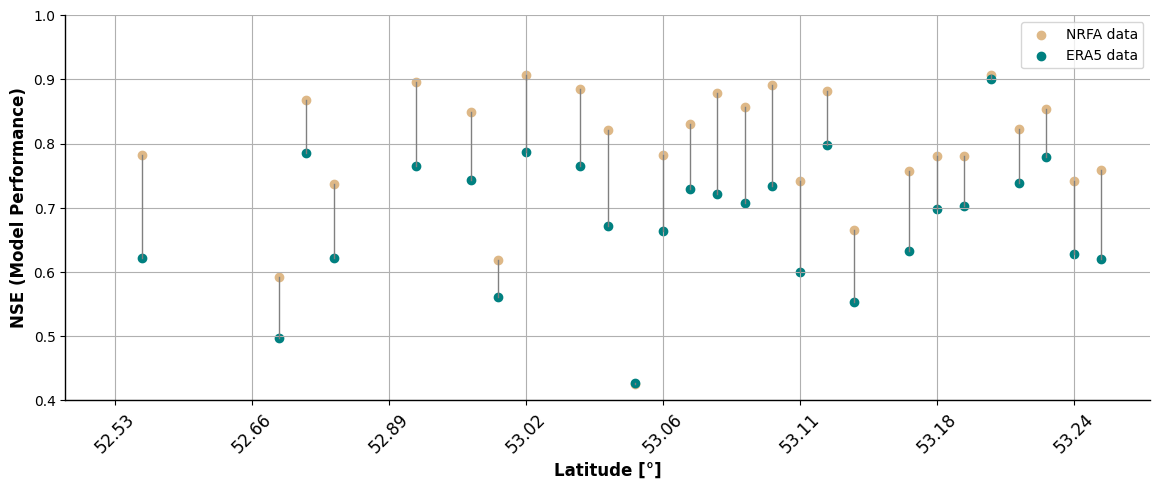

In [228]:
# Sort Dataframe by latitude
sort_param = 'Latitude'#'90 percentile'
comparison = comparison.sort_values(by=sort_param).reset_index(drop=True)
latitude_labels = [round(value, 2) for value in comparison[sort_param]]

catchment_dict ={'7001':'Findhorn',
                 '33039':'Bedford Ouse',
                 '54057':'Severn'}

fig, ax1 = plt.subplots(figsize=(14, 5))

# Plot NSE values for Era5 and NRFA as dots
ax1.scatter(comparison.index, comparison['NSE_NRFA'], color='BurlyWood', label='NRFA data')
ax1.scatter(comparison.index, comparison['NSE_Era5'], color='Teal', label='ERA5 data')

# Draw lines between each pair of dots
for i in range(len(comparison)):
    ax1.plot([i, i], [comparison['NSE_Era5'].iloc[i], comparison['NSE_NRFA'].iloc[i]], color='gray', linestyle='-', linewidth=1)
    
# Add station names next to the focus catchments
param = 'NSE_NRFA'
for j, row in comparison.iterrows():
    if row['Station'] in ['7001','33039','54057']:
        x_offset = 0.1
        y_offset = 0.025
        ax1.text(j + x_offset, row[param] + y_offset, catchment_dict.get(row['Station']), fontsize=9, ha='center')

# Labels and title for the first axis
ax1.set_xlabel('Latitude [°]', fontweight='bold', fontsize=12)
ax1.set_ylabel('NSE')
ax1.set_xticklabels(latitude_labels, rotation=45, fontsize=12)
ax1.set_ylim(0.4,1)
ax1.set_ylabel('NSE (Model Performance)', fontweight='bold', fontsize=12)
ax1.legend(loc='upper right')

ax1.spines['bottom'].set_linewidth(1)
ax1.spines['left'].set_linewidth(1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_color('black')
ax1.spines['left'].set_color('black')

plt.grid(True)
#plt.savefig(f"{paths.IMAGES}/nrfa_vs_era5_modelperformance.png", dpi=300, bbox_inches='tight')
plt.show()